# 01c — Modelos de Embeddings

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Adamychen/m10_quarto/blob/main/notebooks/bloque1/01c-embeddings.ipynb)

> Este tema forma parte del **Bloque 1 — Fundamentos**. Se recomienda
> haber visto [01b-llms.qmd](01b-llms.qmd) primero.

In [1]:
!pip install -q sentence-transformers matplotlib scikit-learn

In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 100
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.

## Modelos de Embeddings

### De word2vec a sentence embeddings

La evolución de la representación vectorial del lenguaje:

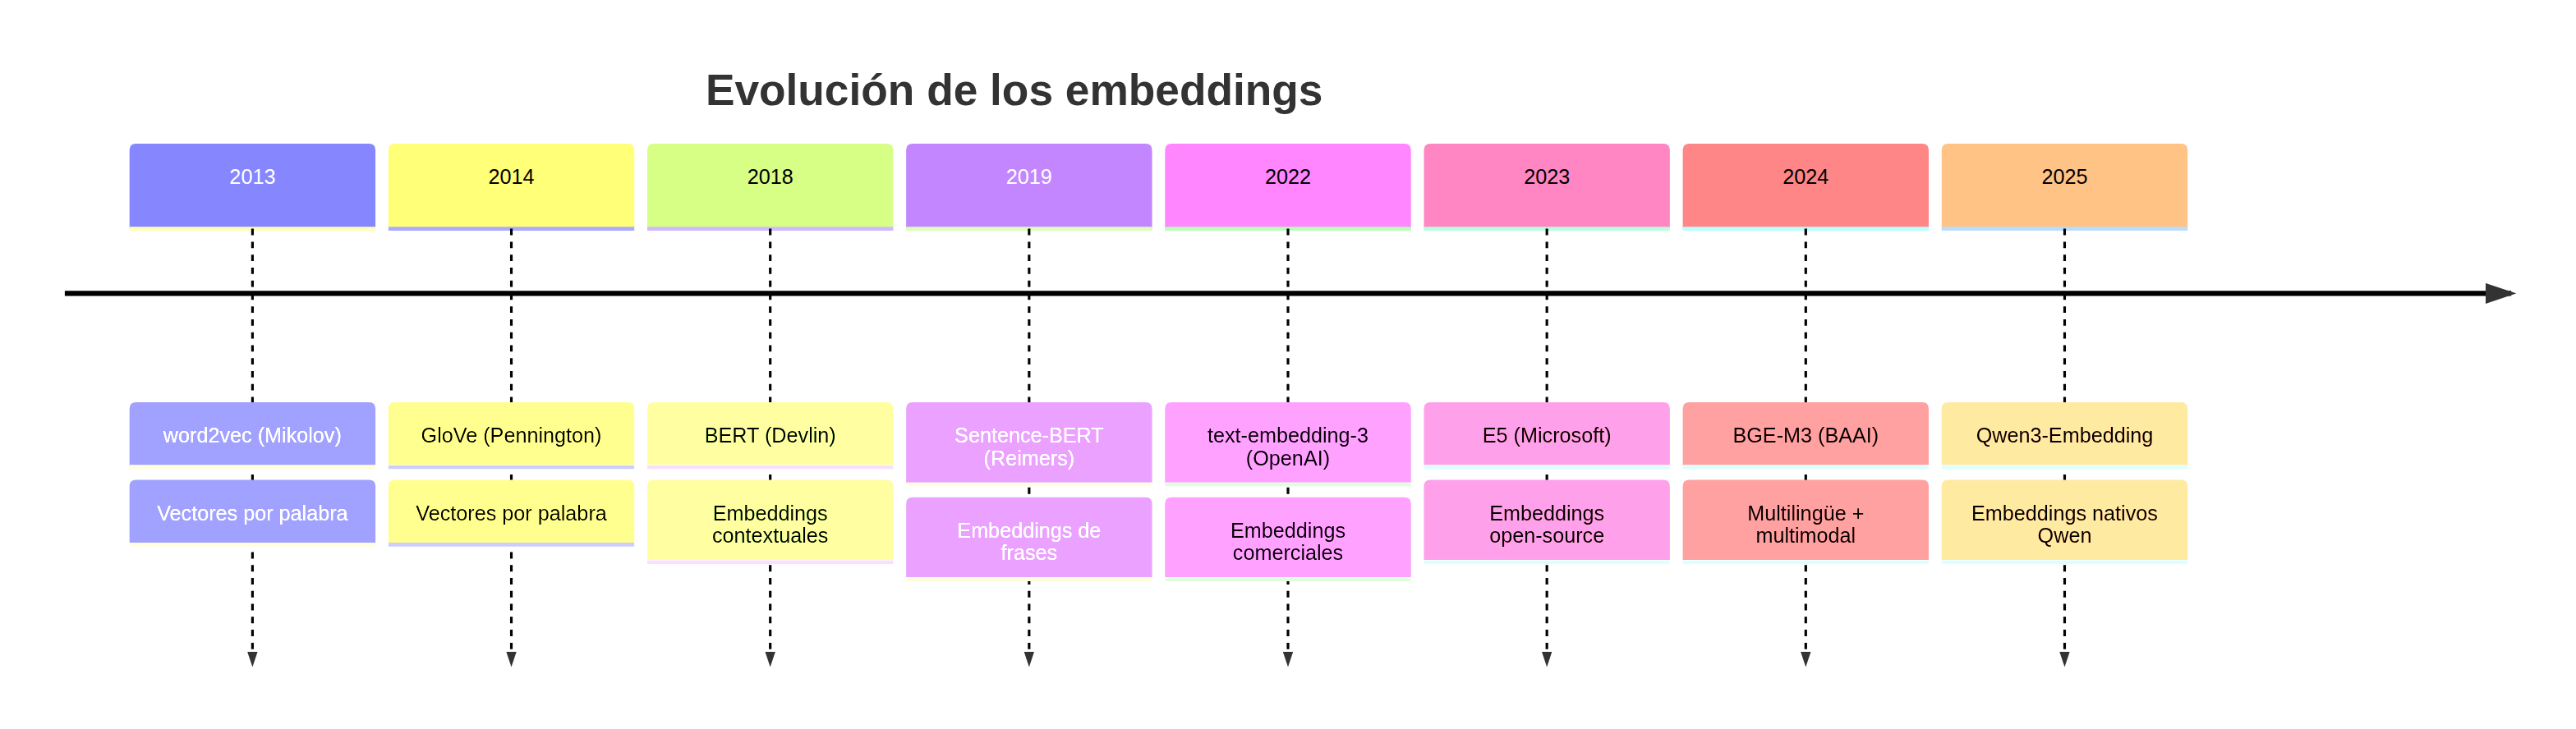

> **Idioma de los textos de ejemplo**
>
> Los modelos de embeddings que usamos en este bloque
> (`all-MiniLM-L6-v2`) están entrenados principalmente en **inglés**.
> Por eso los ejemplos de código utilizan texto en inglés. Cada modelo
> lleva asociado un **tokenizador** entrenado en su idioma: usar un
> tokenizador inglés sobre texto español produce más subtokens por
> palabra y embeddings de menor calidad, porque el espacio semántico
> aprendido está calibrado para relaciones del inglés.
>
> Si necesitas trabajar con español, usa modelos multilingües como
> `intfloat/multilingual-e5-small` o `BAAI/bge-m3`. La API es la misma;
> solo cambia el nombre del modelo.

### Semántica distribucional

El principio fundamental: **“You shall know a word by the company it
keeps”** (Firth, 1957). Palabras con contextos similares tienen
significados similares, y por tanto vectores cercanos en el espacio
semántico.

In [3]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

frases = [
    "A cat plays in the garden",
    "A feline chases a butterfly",
    "The dog sleeps on the rug",
    "Tomorrow will be a sunny day"
]

embeddings = model.encode(frases)
print(f"Forma de los embeddings: {embeddings.shape}")
print(f"Dimensión: {embeddings.shape[1]}")
print(f"Número de frases: {embeddings.shape[0]}")

Forma de los embeddings: (4, 384)
Dimensión: 384
Número de frases: 4

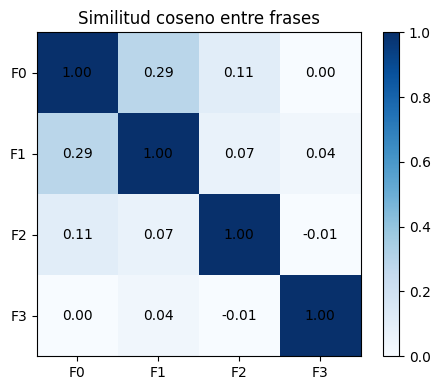

Notice how animal-related phrases (0, 1) have high similarity
while the weather phrase (3) is different from the rest.

In [4]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(embeddings)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(sim_matrix, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(frases)))
ax.set_yticks(range(len(frases)))
ax.set_xticklabels([f"F{i}" for i in range(len(frases))])
ax.set_yticklabels([f"F{i}" for i in range(len(frases))])
ax.set_title("Similitud coseno entre frases")

for i in range(len(frases)):
    for j in range(len(frases)):
        ax.text(j, i, f"{sim_matrix[i, j]:.2f}", ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print("Notice how animal-related phrases (0, 1) have high similarity")
print("while the weather phrase (3) is different from the rest.")

### Sentence-BERT

Sentence-BERT (SBERT) modifica BERT con una arquitectura **siamese** que
permite generar embeddings de frases comparables directamente. Usa
funciones de pérdida contrastiva (triplet loss, cosine similarity loss)
para que frases semánticamente cercanas tengan vectores cercanos.

<figure id="fig-sbert-arch">
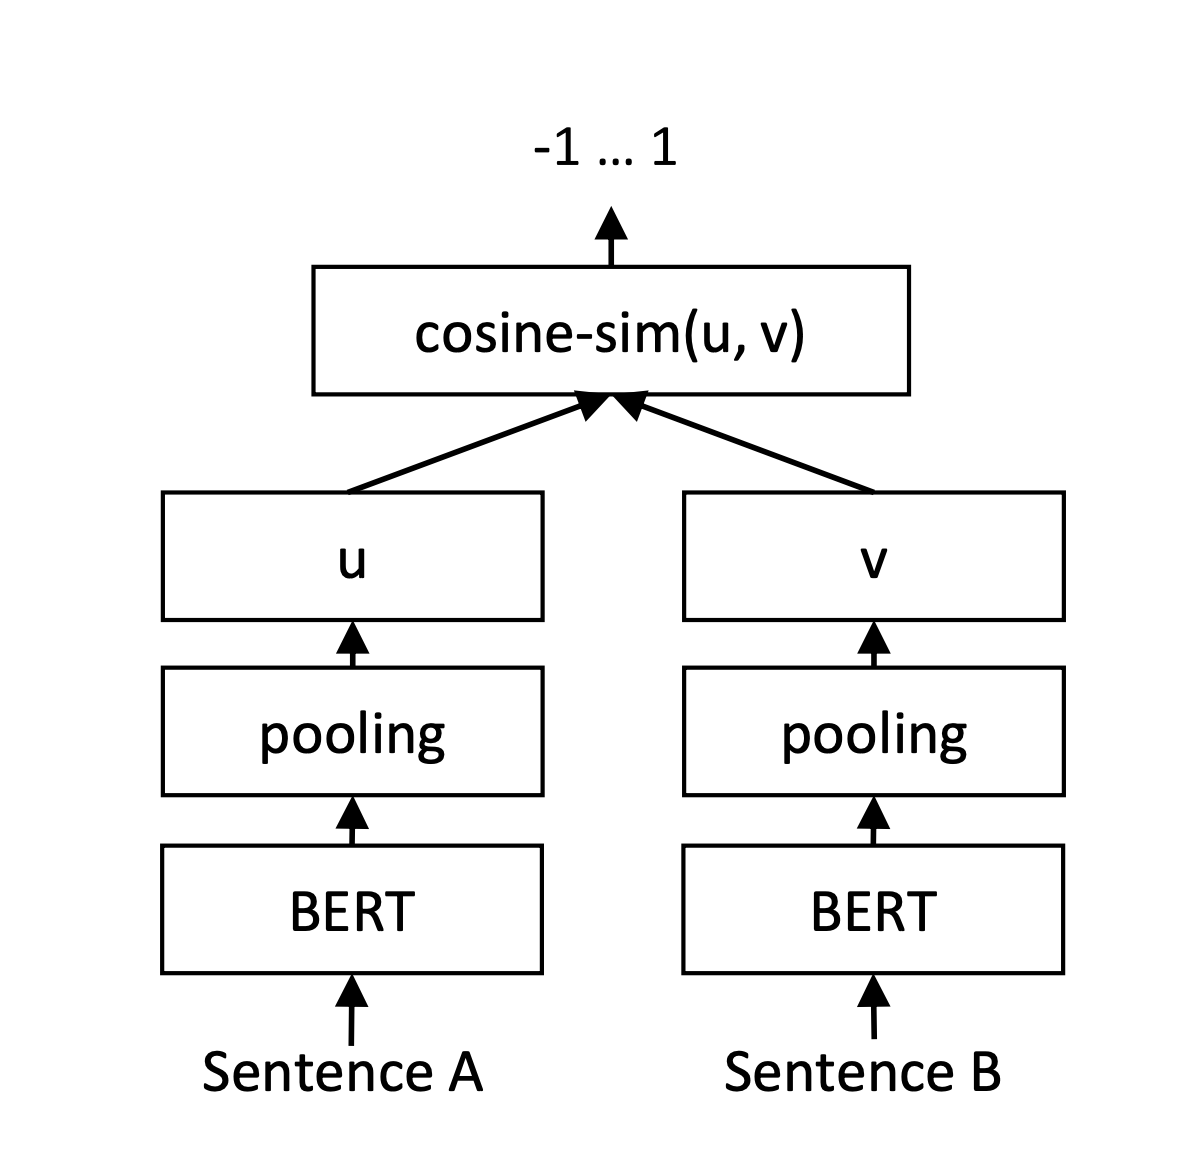
<figcaption>Figure 1: Arquitectura siamese de SBERT para
inferencia.</figcaption>
</figure>

### Comparativa de modelos de embeddings

| Modelo | Dimensiones | Tamaño | Uso |
|------------------|------------------|------------------|------------------|
| `all-MiniLM-L6-v2` | 384 | ~80 MB | Prototipado rápido |
| `intfloat/e5-small-v2` | 384 | ~120 MB | Propósito general open-source |
| `intfloat/e5-base-v2` | 768 | ~440 MB | Mayor precisión |
| `qwen3-embedding:0.6b` | 768 | ~640 MB | Embeddings nativos Qwen (disponible en Llamus) |
| `nomic-embed-text-v2-moe` | 768 | ~475 MB | Alta precisión, MoE eficiente |
| `mxbai-embed-large:v1` | 1024 | ~334 MB | Embeddings densos generales |
| `text-embedding-3-small` | 512 o 1536 | API | Comercial (OpenAI) |
| `text-embedding-3-large` | 256 o 3072 | API | Alta precisión (OpenAI) |

### Embeddings multimodales y tabulares

- **Multimodales (CLIP):** proyectan texto e imágenes en un mismo
  espacio vectorial, permitiendo búsqueda cross-modal (ej. “un perro
  jugando en la nieve” → imágenes correspondientes).
- **Tabulares (TabNet, SCARF):** generan embeddings de filas de datos
  tabulares usando atención, útiles para búsqueda semántica sobre datos
  estructurados (ej. encontrar clientes similares por perfil de compra).

## ¿Cuándo usar cada uno?

- **Texto:** Sentence-BERT / E5 → **Vector DB**
- **Texto + imágenes:** CLIP → **Búsqueda multimodal**
- **Datos tabulares:** TabNet / SCARF → **Búsqueda por perfil**
- **Código:** CodeBERT / GraphCodeBERT → **Búsqueda semántica de
  código**

------------------------------------------------------------------------

> Continúa con **[01d-vectordb.qmd](01d-vectordb.qmd)** — Bases de datos
> vectoriales.